# Experiment: Standard vs Ricci-Based Early Stopping 
**Dataset**: Fashion-MNIST (Sneakers vs Sandals)  

**Goal**: Compare standard patience-based early stopping with Ricci-coefficient-based early stopping across 45 architectures (36 flat + 9 bottleneck).

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os, time, json, copy
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, TensorDataset
from scipy.sparse import csr_matrix, lil_matrix
from scipy.sparse import triu as sp_triu
from scipy.sparse.csgraph import dijkstra
from sklearn.neighbors import kneighbors_graph
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


In [4]:
# ── Experiment Configuration ──
MAX_EPOCHS = 50
PATIENCE = 5
K = 50                    # kNN neighbours for Ricci computation
CURVATURE_TYPE = 'Augmented-Forman-Ricci'
LR = 0.001
BATCH_SIZE = 128

# ── Architecture grid ──
FLAT_DEPTHS = [4, 5, 6, 7, 8, 9, 10, 11, 12]
FLAT_WIDTHS = [16, 32, 64, 128]
BOTTLENECK_DEPTHS = [4, 5, 6, 7, 8, 9, 10, 11, 12]
BOTTLENECK_WIDTH = 128

# Build architecture list: (name, type, depth, width_or_config)
ARCHITECTURES = []
for d in FLAT_DEPTHS:
    for w in FLAT_WIDTHS:
        ARCHITECTURES.append((f'flat_{d}_{w}', 'flat', d, w))
for d in BOTTLENECK_DEPTHS:
    ARCHITECTURES.append((f'bottleneck_{d}_{BOTTLENECK_WIDTH}', 'bottleneck', d, BOTTLENECK_WIDTH))

print(f'Total architectures: {len(ARCHITECTURES)}')
print(f'Flat: {len(FLAT_DEPTHS)*len(FLAT_WIDTHS)}, Bottleneck: {len(BOTTLENECK_DEPTHS)}')

# ── Paths ──
DRIVE_BASE = '/content/drive/MyDrive/Ricci_Flow_Experiment'
OUTPUT_DIR = os.path.join(DRIVE_BASE, 'early_stopping_experiment')
CHECKPOINT_PATH = os.path.join(OUTPUT_DIR, 'checkpoint.json')
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Output: {OUTPUT_DIR}')

Total architectures: 45
Flat: 36, Bottleneck: 9
Output: /content/drive/MyDrive/Ricci_Flow_Experiment/early_stopping_experiment


In [5]:
# ── Load Fashion-MNIST (Sneakers=7 vs Sandals=5) ──
transform = transforms.Compose([transforms.ToTensor()])
train_data = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_data = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

def filter_classes(dataset, class_a=5, class_b=7):
    mask = (dataset.targets == class_a) | (dataset.targets == class_b)
    X = dataset.data[mask].float() / 255.0
    y = dataset.targets[mask].float()
    y = (y == class_b).float()  # Sneakers=1, Sandals=0
    return X.to(device), y.to(device)

X_train, y_train = filter_classes(train_data)
X_test, y_test = filter_classes(test_data)

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Batches per epoch: {len(train_loader)}')
print(f'Class balance — Train: {y_train.mean():.3f}, Test: {y_test.mean():.3f}')

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.82MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.0MB/s]


Train: torch.Size([12000, 28, 28]), Test: torch.Size([2000, 28, 28])
Batches per epoch: 94
Class balance — Train: 0.500, Test: 0.500


In [6]:
def get_bottleneck_widths(depth, max_width):
    """Generate symmetric bottleneck widths.
    E.g. depth=5, max_width=128 -> [128, 64, 32, 64, 128]
    """
    mid = depth // 2
    widths = []
    for i in range(depth):
        dist_from_mid = abs(i - mid)
        if depth % 2 == 0:
            dist_from_mid = abs(i - mid + 0.5) + 0.5
            dist_from_edge = min(i, depth - 1 - i)
        else:
            dist_from_edge = min(i, depth - 1 - i)
        # Each step away from edge halves the width
        reduction = 2 ** (mid - dist_from_edge) if dist_from_edge < mid else 1
        w = max(max_width // reduction, 8)  # minimum width 8
        widths.append(w)
    return widths

class DNN(nn.Module):
    def __init__(self, input_dim=784, layer_widths=None, hidden_units=None, depth=None):
        super().__init__()
        if layer_widths is None:
            layer_widths = [hidden_units] * depth
        self.flatten = nn.Flatten()

        dims = [input_dim] + layer_widths + [1]

        layers = []
        for i in range(len(dims) - 1):
            linear = nn.Linear(dims[i], dims[i + 1])
            nn.init.kaiming_normal_(linear.weight, nonlinearity='relu')
            nn.init.zeros_(linear.bias)
            layers.append(linear)
        self.layers = nn.ModuleList(layers)

        self.batchnorms = nn.ModuleList([
            nn.BatchNorm1d(dims[i + 1]) for i in range(len(dims) - 2)
        ])

    def forward(self, x):
        x = self.flatten(x)
        for i, layer in enumerate(self.layers[:-1]):
            x = layer(x)
            x = self.batchnorms[i](x)
            x = torch.relu(x)
        return self.layers[-1](x)

    def features(self, x):
        x = self.flatten(x)
        features = [x.detach().cpu().numpy()]
        for i, layer in enumerate(self.layers[:-1]):
            x = layer(x)
            x = self.batchnorms[i](x)
            x = torch.relu(x)
            features.append(x.detach().cpu().numpy())
        x = torch.sigmoid(self.layers[-1](x))
        features.append(x.detach().cpu().numpy())
        return features

def build_model(arch_type, depth, width):
    if arch_type == 'bottleneck':
        widths = get_bottleneck_widths(depth, width)
        model = DNN(input_dim=784, layer_widths=widths)
    else:
        model = DNN(input_dim=784, hidden_units=width, depth=depth)
    return model.to(device)

# Test
m = build_model('bottleneck', 5, 128)
print(f'Bottleneck 5/128 widths: {get_bottleneck_widths(5, 128)}')
print(f'Layers: {[(l.in_features, l.out_features) for l in m.layers]}')
m = build_model('flat', 5, 64)
print(f'Flat 5/64 layers: {[(l.in_features, l.out_features) for l in m.layers]}')
del m
print('\u2705 DNN class defined')

Bottleneck 5/128 widths: [32, 64, 128, 64, 32]
Layers: [(784, 32), (32, 64), (64, 128), (128, 64), (64, 32), (32, 1)]
Flat 5/64 layers: [(784, 64), (64, 64), (64, 64), (64, 64), (64, 64), (64, 1)]
✅ DNN class defined


In [7]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    return (correct / len(y_pred)) * 100

def train_one_epoch(model, train_loader, optimizer, loss_fn):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in train_loader:
        y_logits = model(X_batch).squeeze()
        loss = loss_fn(y_logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(X_batch)
    return total_loss / len(train_loader.dataset)

def evaluate(model, X, y):
    model.eval()
    with torch.inference_mode():
        y_logits = model(X).squeeze()
        y_preds = torch.round(torch.sigmoid(y_logits))
        acc = accuracy_fn(y, y_preds) / 100.0
        loss = nn.BCEWithLogitsLoss()(y_logits, y).item()
    return acc, loss

print('\u2705 Training functions defined')

✅ Training functions defined


In [8]:
def compute_forman_ricci(A):
    A = csr_matrix(A)
    degrees = A @ np.ones(A.shape[0])
    Ric = lil_matrix(A.shape, dtype=np.int32)
    rows, cols = sp_triu(A, k=1).nonzero()
    for i, j in zip(rows, cols):
        Ric[i,j] = 4 - degrees[i] - degrees[j]
        Ric[j,i] = Ric[i,j]
    return Ric.tocsr()

def compute_augmented_forman_ricci(A):
    A = csr_matrix(A)
    degrees = A @ np.ones(A.shape[0])
    A2 = A @ A
    Ric = lil_matrix(A.shape, dtype=np.int32)
    rows, cols = sp_triu(A, k=1).nonzero()
    for i, j in zip(rows, cols):
        Ric[i,j] = 4 - degrees[i] - degrees[j] + 3 * A2[i,j]
        Ric[j,i] = Ric[i,j]
    return Ric.tocsr()

def compute_approx_ollivier_ricci(A):
    A = csr_matrix(A)
    degrees = A @ np.ones(A.shape[0])
    A2 = A @ A
    Ric = lil_matrix(A.shape, dtype=np.float32)
    rows, cols = sp_triu(A, k=1).nonzero()
    for i, j in zip(rows, cols):
        t = A2[i,j]; di, dj = degrees[i], degrees[j]
        Ric[i,j] = 0.5*(t/max(di,dj)) - 0.5*(max(0, 1-1/di-1/dj-t/min(di,dj)) + max(0, 1-1/di-1/dj-t/max(di,dj)) - t/max(di,dj))
        Ric[j,i] = Ric[i,j]
    return Ric.tocsr()

def compute_curvature(A, curv):
    if curv == 'Forman-Ricci':             return compute_forman_ricci(A)
    elif curv == 'Augmented-Forman-Ricci':  return compute_augmented_forman_ricci(A)
    elif curv == 'Approx-Ollivier-Ricci':   return compute_approx_ollivier_ricci(A)
    else: raise ValueError(f'Unknown curvature: {curv}')

def compute_ricci_from_features(features, k, curv='Augmented-Forman-Ricci'):
    depth = len(features)
    kNN_graphs = []
    for feat in features:
        g = kneighbors_graph(feat, k, mode='connectivity', include_self=False)
        kNN_graphs.append(g.maximum(g.T))
    apsps = [dijkstra(csgraph=g, directed=False, unweighted=True, return_predecessors=False) for g in kNN_graphs]
    curvatures = [compute_curvature(kNN_graphs[i], curv) for i in range(depth - 1)]
    layer_ricci = np.empty(depth - 1)
    for i in range(depth - 1):
        sc, eta = [], []
        for x in range(len(features[0])):
            S1 = kNN_graphs[i][x].indices
            ec, connected = 0, True
            for y in S1:
                if apsps[i+1][x, y] == np.inf:
                    connected = False
                else:
                    ec += apsps[i+1][x, y] - apsps[i][x, y]
            if connected:
                sc.append(np.divide(curvatures[i][x].sum(), kNN_graphs[i][x].count_nonzero()))
                eta.append(ec / len(S1))
        layer_ricci[i] = pearsonr(sc, eta)[0] if len(sc) >= 2 else np.nan
    return layer_ricci

print('\u2705 Curvature functions defined')

✅ Curvature functions defined


In [9]:
def robust_avg_ricci_iqr(layer_ricci, iqr_factor=1.5):
    """Compute average Ricci excluding outlier layers using the IQR method.

    Uses Tukey's fences: a layer is an outlier if its value exceeds
    Q3 + iqr_factor * IQR. Since 'good' Ricci = more negative,
    outliers are on the HIGH end (close to 0 or positive).

    Parameters
    ----------
    layer_ricci : np.ndarray
        1-D array of per-layer Ricci coefficients.
    iqr_factor : float, default=1.5
        Multiplier for the IQR to define the upper fence.
        1.5 = standard outlier; 3.0 = extreme outlier only.

    Returns
    -------
    avg : float
        The robust average Ricci coefficient.
    excluded_indices : list[int]
        Indices of excluded layers (empty if none were excluded).
    """
    valid_mask = np.isfinite(layer_ricci)
    valid = layer_ricci[valid_mask]

    if len(valid) < 3:
        return float(np.nanmean(layer_ricci)), []

    q1, q3 = np.percentile(valid, [25, 75])
    iqr = q3 - q1
    upper_bound = q3 + iqr_factor * iqr

    excluded_indices = []
    kept_values = []
    for i, val in enumerate(layer_ricci):
        if not np.isfinite(val):
            continue
        if val > upper_bound:
            excluded_indices.append(i)
        else:
            kept_values.append(val)

    if len(kept_values) == 0:
        return float(np.nanmean(layer_ricci)), []

    return float(np.mean(kept_values)), excluded_indices


# ═══════════════════════════════════════════════════════════════════════
# OPTION B: Adaptive Z-Score Trimming (MAD-based)
# ═══════════════════════════════════════════════════════════════════════

def robust_avg_ricci_zscore(layer_ricci, z_thresh=2.0):
    """Compute average Ricci excluding layers that deviate too far from
    the median, measured in MAD (Median Absolute Deviation) units.

    Only rejects high-side outliers (layers closer to 0 than the cluster).
    The consistency constant 1.4826 makes MAD comparable to standard
    deviation under normality — a well-known convention in robust statistics.

    Parameters
    ----------
    layer_ricci : np.ndarray
        1-D array of per-layer Ricci coefficients.
    z_thresh : float, default=2.0
        Number of MAD units above the median to consider as outlier.

    Returns
    -------
    avg : float
        The robust average Ricci coefficient.
    excluded_indices : list[int]
        Indices of excluded layers (empty if none were excluded).
    """
    valid_mask = np.isfinite(layer_ricci)
    valid = layer_ricci[valid_mask]

    if len(valid) < 3:
        return float(np.nanmean(layer_ricci)), []

    median = np.median(valid)
    mad = np.median(np.abs(valid - median))

    if mad < 1e-10:  # all layers nearly identical
        return float(np.mean(valid)), []

    # 1.4826 = consistency constant (makes MAD ~ std dev for normal data)
    upper_bound = median + z_thresh * mad * 1.4826

    excluded_indices = []
    kept_values = []
    for i, val in enumerate(layer_ricci):
        if not np.isfinite(val):
            continue
        if val > upper_bound:
            excluded_indices.append(i)
        else:
            kept_values.append(val)

    if len(kept_values) == 0:
        return float(np.nanmean(layer_ricci)), []

    return float(np.mean(kept_values)), excluded_indices


# ═══════════════════════════════════════════════════════════════════════
# OPTION C: Progressive Trimming (Iterative)
# ═══════════════════════════════════════════════════════════════════════

def robust_avg_ricci_progressive(layer_ricci, max_trim_ratio=0.3, cv_threshold=0.15):
    """Iteratively remove the most extreme (highest / closest to 0) layer
    until the remaining layers form a tight cluster, or we've trimmed
    up to max_trim_ratio of the layers.

    Parameters
    ----------
    layer_ricci : np.ndarray
        1-D array of per-layer Ricci coefficients.
    max_trim_ratio : float, default=0.3
        Maximum fraction of layers that can be removed (e.g., 0.3 = 30%).
    cv_threshold : float, default=0.15
        Target coefficient of variation. Iteration stops when CV drops
        below this value.

    Returns
    -------
    avg : float
        The robust average Ricci coefficient.
    excluded_indices : list[int]
        Indices of excluded layers (empty if none were excluded).
    """
    valid_mask = np.isfinite(layer_ricci)
    valid = layer_ricci[valid_mask]

    if len(valid) < 3:
        return float(np.nanmean(layer_ricci)), []

    # Track original indices of valid values
    valid_indices = [i for i, v in enumerate(layer_ricci) if np.isfinite(v)]
    working = list(zip(valid_indices, valid))  # [(orig_idx, value), ...]

    max_removals = max(1, int(len(working) * max_trim_ratio))
    excluded_indices = []

    for _ in range(max_removals):
        if len(working) < 3:
            break

        values = np.array([v for _, v in working])
        mean_val = np.mean(values)

        if abs(mean_val) < 1e-10:
            break

        cv = np.std(values) / abs(mean_val)
        if cv < cv_threshold:
            break

        # Find the most positive (worst) value and remove it
        worst_pos = int(np.argmax(values))
        excluded_indices.append(working[worst_pos][0])
        working.pop(worst_pos)

    if len(working) == 0:
        return float(np.nanmean(layer_ricci)), []

    return float(np.mean([v for _, v in working])), excluded_indices

# ═══════════════════════════════════════════════════════════════════════
# OPTION D: Rule-Based Tail Drop
# ═══════════════════════════════════════════════════════════════════════

def robust_avg_ricci_tail_drop(layer_ricci, shallow_threshold=7):
    """Compute average Ricci by dropping the last N layers based on
    a simple depth-dependent rule:

      - If total layers < shallow_threshold: exclude the LAST 1 layer
      - If total layers >= shallow_threshold: exclude the LAST 2 layers

    This is motivated by the observation that the final transition(s)
    to the narrow output layer produce degenerate Ricci coefficients,
    and deeper networks tend to have more layers affected.

    Parameters
    ----------
    layer_ricci : np.ndarray
        1-D array of per-layer Ricci coefficients.
    shallow_threshold : int, default=7
        Layer count below which only 1 layer is dropped (instead of 2).

    Returns
    -------
    avg : float
        The average Ricci coefficient after dropping tail layers.
    excluded_indices : list[int]
        Indices of excluded (dropped) layers.
    """
    valid_mask = np.isfinite(layer_ricci)
    valid_indices = [i for i, m in enumerate(valid_mask) if m]
    n_valid = len(valid_indices)

    if n_valid == 0:
        return float(np.nan), []

    if n_valid <= 2:
        # Too few layers to drop any — just return the mean
        return float(np.nanmean(layer_ricci)), []

    # Decide how many to drop from the tail
    n_drop = 1 if n_valid < shallow_threshold else 2

    # The excluded indices are the LAST n_drop valid layers
    excluded_indices = valid_indices[-n_drop:]
    kept_indices = valid_indices[:-n_drop]

    if len(kept_indices) == 0:
        return float(np.nanmean(layer_ricci)), []

    kept_values = [layer_ricci[i] for i in kept_indices]
    return float(np.mean(kept_values)), excluded_indices


# ═══════════════════════════════════════════════════════════════════════
# OPTION E: Fixed Threshold Filter
# ═══════════════════════════════════════════════════════════════════════

def robust_avg_ricci_threshold(layer_ricci, threshold=-0.6):
    """Compute average Ricci using only layers whose coefficient is
    below the given threshold.

    Layers with Ricci >= threshold are considered geometrically
    degenerate and excluded from the average.

    Parameters
    ----------
    layer_ricci : np.ndarray
        1-D array of per-layer Ricci coefficients.
    threshold : float, default=-0.55
        Only layers with Ricci < threshold are included in the average.

    Returns
    -------
    avg : float
        The average of layers that pass the threshold.
    excluded_indices : list[int]
        Indices of excluded layers.
    """
    excluded_indices = []
    kept_values = []

    for i, val in enumerate(layer_ricci):
        if not np.isfinite(val):
            continue
        if val >= threshold:
            excluded_indices.append(i)
        else:
            kept_values.append(val)

    if len(kept_values) == 0:
        # No layer passed the threshold — fall back to plain mean
        return float(np.nanmean(layer_ricci)), []

    return float(np.mean(kept_values)), excluded_indices



In [10]:
class StandardEarlyStopping:
    """Passive observer: tracks when patience-based ES on test accuracy would stop.
    Patience counter activates only after acc changes from its initial value."""
    def __init__(self, patience=5):
        self.patience = patience
        self.initial_acc = None
        self.activated = False
        self.best_acc = -1.0
        self.best_epoch = None
        self.wait = 0
        self.stop_epoch = None

    def step(self, epoch, val_acc):
        if self.stop_epoch is not None:
            return

        if self.initial_acc is None:
            self.initial_acc = float(val_acc)
            self.best_acc = float(val_acc)
            self.best_epoch = epoch
            return

        if not self.activated:
            if val_acc != self.initial_acc:
                self.activated = True
                self.best_acc = float(val_acc)
                self.best_epoch = epoch
                self.wait = 0
            return

        if val_acc > self.best_acc:
            self.best_acc = float(val_acc)
            self.best_epoch = epoch
            self.wait = 0
        else:
            self.wait += 1

        if self.wait >= self.patience:
            self.stop_epoch = epoch

class RicciEarlyStopping:
    """Passive observer: tracks when patience-based ES on avg Ricci would stop.
    Lower (more negative) avg_ricci = better (closer to -1).
    Patience counter activates only after avg_ricci changes from its initial value."""
    def __init__(self, patience=5):
        self.patience = patience
        self.initial_ricci = None
        self.activated = False
        self.best_ricci = None
        self.best_epoch = None
        self.wait = 0
        self.stop_epoch = None

    def step(self, epoch, avg_ricci):
        if self.stop_epoch is not None:
            return

        if not np.isfinite(avg_ricci):
            return

        if self.initial_ricci is None:
            self.initial_ricci = float(avg_ricci)
            self.best_ricci = float(avg_ricci)
            self.best_epoch = epoch
            return

        if not self.activated:
            if avg_ricci != self.initial_ricci:
                self.activated = True
                self.best_ricci = float(avg_ricci)
                self.best_epoch = epoch
                self.wait = 0
            return

        if avg_ricci < self.best_ricci:
            self.best_ricci = float(avg_ricci)
            self.best_epoch = epoch
            self.wait = 0
        else:
            self.wait += 1

        if self.wait >= self.patience:
            self.stop_epoch = epoch

print('✅ Early stopping classes defined')


✅ Early stopping classes defined


In [11]:
results_all = []

for arch_idx, (name, arch_type, depth, width) in enumerate(ARCHITECTURES):
    model_dir = os.path.join(OUTPUT_DIR, name)
    hist_path = os.path.join(model_dir, 'epoch_history.json')

    if not os.path.exists(hist_path):
        print(f'[{arch_idx+1}/{len(ARCHITECTURES)}] {name} — SKIPPED (no epoch_history.json)')
        continue

    print(f'\n{"="*60}')
    print(f'[{arch_idx+1}/{len(ARCHITECTURES)}] {name} (type={arch_type}, depth={depth}, width={width})')
    print(f'{"="*60}')

    # Load saved epoch history
    with open(hist_path, 'r') as f:
        epoch_data = json.load(f)

    # Re-create early stopping observers
    std_es = StandardEarlyStopping(patience=PATIENCE)
    ricci_es = RicciEarlyStopping(patience=PATIENCE)

    std_best_epoch_acc = None
    ricci_best_epoch_acc = None

    for entry in epoch_data:
        epoch = entry['epoch']
        test_acc = entry['test_acc']
        train_acc = entry['train_acc']
        layer_ricci = np.array(entry['layer_ricci'])

        # ── KEY CHANGE: Use robust_avg_ricci instead of np.nanmean ──
        avg_ricci, excluded_layers = robust_avg_ricci_threshold(layer_ricci)

        # Standard ES (passive observer on test accuracy)
        std_es.step(epoch, test_acc)
        if std_es.best_epoch == epoch:
            std_best_epoch_acc = test_acc

        if std_es.stop_epoch == epoch:
            print(
                f'  Epoch {epoch}: STANDARD ES triggered '
                f'(best_epoch={std_es.best_epoch}, best_acc={std_es.best_acc:.4f})'
            )

        # Ricci ES (passive observer on robust avg ricci)
        ricci_es.step(epoch, avg_ricci)
        if ricci_es.best_epoch == epoch:
            ricci_best_epoch_acc = test_acc

        if ricci_es.stop_epoch == epoch:
            print(
                f'  Epoch {epoch}: RICCI ES triggered '
                f'(best_epoch={ricci_es.best_epoch}, best_avg_ricci={ricci_es.best_ricci:.4f})'
            )

        if excluded_layers:
            pass  # Uncomment next line for verbose output:
            # print(f'    [IQR] Excluded layers {excluded_layers} from avg Ricci')

        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch}: train_acc={train_acc:.4f}, test_acc={test_acc:.4f}, avg_ricci={avg_ricci:.4f}')

    # ── Compile results ──
    last_epoch = len(epoch_data) - 1
    std_report_epoch = std_es.best_epoch if std_es.best_epoch is not None else last_epoch
    ricci_report_epoch = ricci_es.best_epoch if ricci_es.best_epoch is not None else last_epoch
    std_report_epoch = max(0, min(int(std_report_epoch), last_epoch))
    ricci_report_epoch = max(0, min(int(ricci_report_epoch), last_epoch))

    std_acc = float(epoch_data[std_report_epoch]['test_acc'])
    ricci_acc = float(epoch_data[ricci_report_epoch]['test_acc'])

    result = {
        'name': name,
        'type': arch_type,
        'depth': depth,
        'width': width,
        'std_es_epoch': std_report_epoch,
        'ricci_es_epoch': ricci_report_epoch,
        'std_es_acc': std_acc,
        'ricci_es_acc': ricci_acc,
    }
    results_all.append(result)

    std_status = f'epoch {std_es.stop_epoch}' if std_es.stop_epoch is not None else 'never triggered'
    ricci_status = f'epoch {ricci_es.stop_epoch}' if ricci_es.stop_epoch is not None else 'never triggered'

    print(f'  Standard ES: best_epoch={std_report_epoch} (acc={std_acc:.4f}) [{std_status}]')
    print(f'  Ricci ES:    best_epoch={ricci_report_epoch} (acc={ricci_acc:.4f}) [{ricci_status}]')

# Save results
with open(os.path.join(OUTPUT_DIR, 'results_summary_robust.json'), 'w') as f:
    json.dump(results_all, f, indent=2)

print(f'\n✅ Retroactive analysis done! {len(results_all)} models processed.')
print(f'Results saved to {os.path.join(OUTPUT_DIR, "results_summary_robust.json")}')



[1/45] flat_4_16 (type=flat, depth=4, width=16)
  Epoch 9: train_acc=0.9820, test_acc=0.9690, avg_ricci=-0.6032
  Epoch 12: RICCI ES triggered (best_epoch=7, best_avg_ricci=-0.6496)
  Epoch 19: STANDARD ES triggered (best_epoch=14, best_acc=0.9740)
  Epoch 19: train_acc=0.9980, test_acc=0.9695, avg_ricci=-0.3411
  Epoch 29: train_acc=0.9992, test_acc=0.9720, avg_ricci=-0.3623
  Epoch 39: train_acc=0.9984, test_acc=0.9705, avg_ricci=-0.3362
  Epoch 49: train_acc=0.9999, test_acc=0.9735, avg_ricci=-0.3451
  Standard ES: best_epoch=14 (acc=0.9740) [epoch 19]
  Ricci ES:    best_epoch=7 (acc=0.9670) [epoch 12]

[2/45] flat_4_32 (type=flat, depth=4, width=32)
  Epoch 9: train_acc=0.9956, test_acc=0.9775, avg_ricci=-0.6148
  Epoch 13: RICCI ES triggered (best_epoch=8, best_avg_ricci=-0.6302)
  Epoch 16: STANDARD ES triggered (best_epoch=11, best_acc=0.9805)
  Epoch 19: train_acc=0.9983, test_acc=0.9775, avg_ricci=-0.6037
  Epoch 29: train_acc=1.0000, test_acc=0.9800, avg_ricci=-0.4209
  Epo

In [12]:
def load_checkpoint():
    if os.path.exists(CHECKPOINT_PATH):
        with open(CHECKPOINT_PATH, 'r') as f:
            return json.load(f)
    return {'completed_models': []}

def save_checkpoint(completed_models):
    with open(CHECKPOINT_PATH, 'w') as f:
        json.dump({'completed_models': completed_models}, f)

print('\u2705 Checkpoint utilities defined')

✅ Checkpoint utilities defined


In [13]:
# ── Main Experiment Loop ──
checkpoint = load_checkpoint()
completed = set(checkpoint['completed_models'])
print(f'Resuming: {len(completed)} models already completed')

results_all = []
_summary_path = os.path.join(OUTPUT_DIR, 'results_summary.json')
if os.path.exists(_summary_path):
    with open(_summary_path, 'r') as f:
        results_all = json.load(f)

t_total = time.time()

for arch_idx, (name, arch_type, depth, width) in enumerate(ARCHITECTURES):
    if name in completed:
        print(f'[{arch_idx+1}/{len(ARCHITECTURES)}] {name} — SKIPPED (already done)')
        continue

    print(f'\n{"="*60}')
    print(f'[{arch_idx+1}/{len(ARCHITECTURES)}] {name} (type={arch_type}, depth={depth}, width={width})')
    print(f'{"="*60}')

    model_dir = os.path.join(OUTPUT_DIR, name)
    os.makedirs(model_dir, exist_ok=True)

    model = build_model(arch_type, depth, width)
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    std_es = StandardEarlyStopping(patience=PATIENCE)
    ricci_es = RicciEarlyStopping(patience=PATIENCE)

    std_best_weights = None
    ricci_best_weights = None

    epoch_data = []

    for epoch in range(MAX_EPOCHS):
        # 1. Train one epoch (mini-batch)
        train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn)

        # 2. Evaluate
        test_acc, test_loss = evaluate(model, X_test, y_test)
        train_acc, _ = evaluate(model, X_train, y_train)

        # 3. Extract activations & compute Ricci
        model.eval()
        with torch.inference_mode():
            features = model.features(X_test)

        hidden_acts = features[1:]
        if len(hidden_acts) < 2:
            raise ValueError(f'{name}: expected at least 2 feature tensors, got {len(hidden_acts)}')

        penultimate_acts = hidden_acts[-2]
        output_acts = hidden_acts[-1]

        if penultimate_acts.ndim != 2 or output_acts.ndim != 2:
            raise ValueError(
                f'{name}: expected 2D activations, got penultimate={penultimate_acts.shape}, output={output_acts.shape}'
            )

        if penultimate_acts.shape[0] != output_acts.shape[0]:
            raise ValueError(
                f'{name}: sample dimension mismatch for last transition: '
                f'penultimate={penultimate_acts.shape}, output={output_acts.shape}'
            )

        layer_ricci = compute_ricci_from_features(hidden_acts, K, curv=CURVATURE_TYPE)
        avg_ricci, excluded_layers = robust_avg_ricci_threshold(layer_ricci)
        last_transition_ricci = float(layer_ricci[-1]) if len(layer_ricci) > 0 else np.nan

        # 4A. Standard ES (passive observer)
        std_es.step(epoch, test_acc)

        if std_es.best_epoch == epoch:
            std_best_weights = copy.deepcopy(model.state_dict())

        if std_es.stop_epoch == epoch:
            print(
                f'  Epoch {epoch}: STANDARD ES would stop '
                f'(best_epoch={std_es.best_epoch}, best_acc={std_es.best_acc:.4f})'
            )

        # 4B. Ricci ES (passive observer)
        ricci_es.step(epoch, avg_ricci)

        if ricci_es.best_epoch == epoch:
            ricci_best_weights = copy.deepcopy(model.state_dict())

        if ricci_es.stop_epoch == epoch:
            print(
                f'  Epoch {epoch}: RICCI ES would stop '
                f'(best_epoch={ricci_es.best_epoch}, best_avg_ricci={ricci_es.best_ricci:.4f})'
            )

        # 5. Save epoch data
        epoch_dir = os.path.join(model_dir, f'epoch_{epoch:03d}')
        os.makedirs(epoch_dir, exist_ok=True)

        act_arr = np.empty(len(hidden_acts), dtype=object)
        for i, a in enumerate(hidden_acts):
            act_arr[i] = a
        np.save(os.path.join(epoch_dir, 'activations.npy'), act_arr)
        np.save(os.path.join(epoch_dir, 'layer_ricci.npy'), layer_ricci)
        np.save(os.path.join(epoch_dir, 'accuracy.npy'), np.array([train_acc, test_acc]))

        epoch_data.append({
            'epoch': epoch,
            'train_acc': float(train_acc),
            'test_acc': float(test_acc),
            'train_loss': float(train_loss),
            'test_loss': float(test_loss),
            'avg_ricci': float(avg_ricci),
            'last_transition_ricci': float(last_transition_ricci),
            'layer_ricci': layer_ricci.tolist()
        })

        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch}: train_acc={train_acc:.4f}, test_acc={test_acc:.4f}, avg_ricci={avg_ricci:.4f}')

        # No break — training runs to MAX_EPOCHS, both ES are passive observers

    # ── Save final results ──
    last_epoch = len(epoch_data) - 1
    if last_epoch < 0:
        raise RuntimeError(f'{name}: no epoch data was recorded.')

    if std_best_weights is not None:
        torch.save(std_best_weights, os.path.join(model_dir, 'model_weights_standard.pth'))
    else:
        torch.save(model.state_dict(), os.path.join(model_dir, 'model_weights_standard.pth'))

    if ricci_best_weights is not None:
        torch.save(ricci_best_weights, os.path.join(model_dir, 'model_weights_ricci.pth'))
    else:
        torch.save(model.state_dict(), os.path.join(model_dir, 'model_weights_ricci.pth'))

    # Report accuracy at best_epoch (the epoch each ES would have chosen)
    std_report_epoch = std_es.best_epoch if std_es.best_epoch is not None else last_epoch
    ricci_report_epoch = ricci_es.best_epoch if ricci_es.best_epoch is not None else last_epoch

    std_report_epoch = max(0, min(int(std_report_epoch), last_epoch))
    ricci_report_epoch = max(0, min(int(ricci_report_epoch), last_epoch))

    std_acc = float(epoch_data[std_report_epoch]['test_acc'])
    ricci_acc = float(epoch_data[ricci_report_epoch]['test_acc'])

    result = {
        'name': name,
        'type': arch_type,
        'depth': depth,
        'width': width,

        'std_es_stopped': std_es.stop_epoch is not None,
        'ricci_es_stopped': ricci_es.stop_epoch is not None,

        'std_best_epoch': std_es.best_epoch,
        'ricci_best_epoch': ricci_es.best_epoch,

        'std_stop_epoch': std_es.stop_epoch,
        'ricci_stop_epoch': ricci_es.stop_epoch,

        'std_report_epoch': std_report_epoch,
        'ricci_report_epoch': ricci_report_epoch,

        'std_es_epoch': std_report_epoch,
        'ricci_es_epoch': ricci_report_epoch,

        'std_es_acc': std_acc,
        'ricci_es_acc': ricci_acc,

        'total_epochs': len(epoch_data)
    }
    results_all.append(result)

    np.save(os.path.join(model_dir, 'standard_es_epoch.npy'), np.array([std_report_epoch]))
    np.save(os.path.join(model_dir, 'ricci_es_epoch.npy'), np.array([ricci_report_epoch]))
    np.save(os.path.join(model_dir, 'standard_es_accuracy.npy'), np.array([std_acc]))
    np.save(os.path.join(model_dir, 'ricci_es_accuracy.npy'), np.array([ricci_acc]))

    with open(os.path.join(model_dir, 'epoch_history.json'), 'w') as f:
        json.dump(epoch_data, f, indent=2)

    std_status = f'would stop at ep {std_es.stop_epoch}' if std_es.stop_epoch is not None else 'never triggered'
    ricci_status = f'would stop at ep {ricci_es.stop_epoch}' if ricci_es.stop_epoch is not None else 'never triggered'

    print(f'  Standard ES: best_epoch={std_report_epoch} (acc={std_acc:.4f}) [{std_status}]')
    print(f'  Ricci ES:    best_epoch={ricci_report_epoch} (acc={ricci_acc:.4f}) [{ricci_status}]')

    completed.add(name)
    save_checkpoint(list(completed))

    del model, optimizer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

with open(os.path.join(OUTPUT_DIR, 'results_summary.json'), 'w') as f:
    json.dump(results_all, f, indent=2)

print(f'\n✅ All done in {time.time()-t_total:.0f}s')


Resuming: 45 models already completed
[1/45] flat_4_16 — SKIPPED (already done)
[2/45] flat_4_32 — SKIPPED (already done)
[3/45] flat_4_64 — SKIPPED (already done)
[4/45] flat_4_128 — SKIPPED (already done)
[5/45] flat_5_16 — SKIPPED (already done)
[6/45] flat_5_32 — SKIPPED (already done)
[7/45] flat_5_64 — SKIPPED (already done)
[8/45] flat_5_128 — SKIPPED (already done)
[9/45] flat_6_16 — SKIPPED (already done)
[10/45] flat_6_32 — SKIPPED (already done)
[11/45] flat_6_64 — SKIPPED (already done)
[12/45] flat_6_128 — SKIPPED (already done)
[13/45] flat_7_16 — SKIPPED (already done)
[14/45] flat_7_32 — SKIPPED (already done)
[15/45] flat_7_64 — SKIPPED (already done)
[16/45] flat_7_128 — SKIPPED (already done)
[17/45] flat_8_16 — SKIPPED (already done)
[18/45] flat_8_32 — SKIPPED (already done)
[19/45] flat_8_64 — SKIPPED (already done)
[20/45] flat_8_128 — SKIPPED (already done)
[21/45] flat_9_16 — SKIPPED (already done)
[22/45] flat_9_32 — SKIPPED (already done)
[23/45] flat_9_64 — 

In [ ]:
# ── Rebuild results_summary.json from per-model folders ──

def rebuild_results_summary(output_dir=None):
    if output_dir is None:
        output_dir = OUTPUT_DIR
    results = []
    for name in sorted(os.listdir(output_dir)):
        model_dir = os.path.join(output_dir, name)
        if not os.path.isdir(model_dir):
            continue
        std_ep_path = os.path.join(model_dir, 'standard_es_epoch.npy')
        ricci_ep_path = os.path.join(model_dir, 'ricci_es_epoch.npy')
        std_acc_path = os.path.join(model_dir, 'standard_es_accuracy.npy')
        ricci_acc_path = os.path.join(model_dir, 'ricci_es_accuracy.npy')
        if not all(os.path.exists(p) for p in [std_ep_path, ricci_ep_path, std_acc_path, ricci_acc_path]):
            continue
        std_epoch = int(np.load(std_ep_path)[0])
        ricci_epoch = int(np.load(ricci_ep_path)[0])
        std_acc = float(np.load(std_acc_path)[0])
        ricci_acc = float(np.load(ricci_acc_path)[0])
        # Infer type, depth, width from folder name (flat_D_W or bottleneck_D_128)
        if name.startswith('flat_'):
            parts = name.replace('flat_', '').split('_')
            arch_type, depth, width = 'flat', int(parts[0]), int(parts[1])
        elif name.startswith('bottleneck_'):
            parts = name.replace('bottleneck_', '').split('_')
            arch_type, depth, width = 'bottleneck', int(parts[0]), int(parts[1])
        else:
            continue
        total_epochs = 0
        hist_path = os.path.join(model_dir, 'epoch_history.json')
        if os.path.exists(hist_path):
            with open(hist_path, 'r') as f:
                total_epochs = len(json.load(f))
        results.append({
            'name': name, 'type': arch_type, 'depth': depth, 'width': width,
            'std_es_epoch': std_epoch, 'std_es_acc': std_acc,
            'ricci_es_epoch': ricci_epoch, 'ricci_es_acc': ricci_acc,
            'total_epochs': total_epochs
        })
    out_path = os.path.join(output_dir, 'results_summary.json')
    with open(out_path, 'w') as f:
        json.dump(results, f, indent=2)
    print(f'Rebuilt results_summary.json with {len(results)} architectures from {output_dir}')
    return results

# Run and optionally assign to results_all for downstream cells
results_all = rebuild_results_summary()

Rebuilt results_summary.json with 45 architectures from /content/drive/MyDrive/Ricci_Flow_Experiment/early_stopping_experiment


In [ ]:
# ── Results Summary Table ──
# Load results
if not results_all:
    with open(os.path.join(OUTPUT_DIR, 'results_summary.json'), 'r') as f:
        results_all = json.load(f)

print(f'{"Architecture":<24} {"Std ES Epoch":>13} {"Std Acc":>9} {"Ricci ES Epoch":>15} {"Ricci Acc":>10} {"Winner":>8}')
print('-' * 85)
for r in results_all:
    winner = 'Ricci' if r['ricci_es_epoch'] < r['std_es_epoch'] else ('Std' if r['std_es_epoch'] < r['ricci_es_epoch'] else 'Tie')
    print(f'{r["name"]:<24} {r["std_es_epoch"]:>13} {r["std_es_acc"]:>9.4f} {r["ricci_es_epoch"]:>15} {r["ricci_es_acc"]:>10.4f} {winner:>8}')

# Summary stats
ricci_wins = sum(1 for r in results_all if r['ricci_es_epoch'] < r['std_es_epoch'])
std_wins = sum(1 for r in results_all if r['std_es_epoch'] < r['ricci_es_epoch'])
ties = sum(1 for r in results_all if r['std_es_epoch'] == r['ricci_es_epoch'])
print(f'\nRicci earlier: {ricci_wins}, Standard earlier: {std_wins}, Tie: {ties}')

avg_ricci_acc = np.mean([r['ricci_es_acc'] for r in results_all])
avg_std_acc = np.mean([r['std_es_acc'] for r in results_all])
print(f'Avg accuracy — Standard: {avg_std_acc:.4f}, Ricci: {avg_ricci_acc:.4f}')

Architecture              Std ES Epoch   Std Acc  Ricci ES Epoch  Ricci Acc   Winner
-------------------------------------------------------------------------------------
bottleneck_10_128                   25    0.9695               1     0.8900    Ricci
bottleneck_11_128                   25    0.9630               2     0.9135    Ricci
bottleneck_12_128                   20    0.9680               1     0.9040    Ricci
bottleneck_4_128                    12    0.9795              13     0.9770      Std
bottleneck_5_128                    11    0.9780              16     0.9700      Std
bottleneck_6_128                     5    0.9730              11     0.9715      Std
bottleneck_7_128                    15    0.9765               8     0.9730    Ricci
bottleneck_8_128                    13    0.9635               1     0.8990    Ricci
bottleneck_9_128                    13    0.9630               1     0.9040    Ricci
flat_10_128                          4    0.9765              18

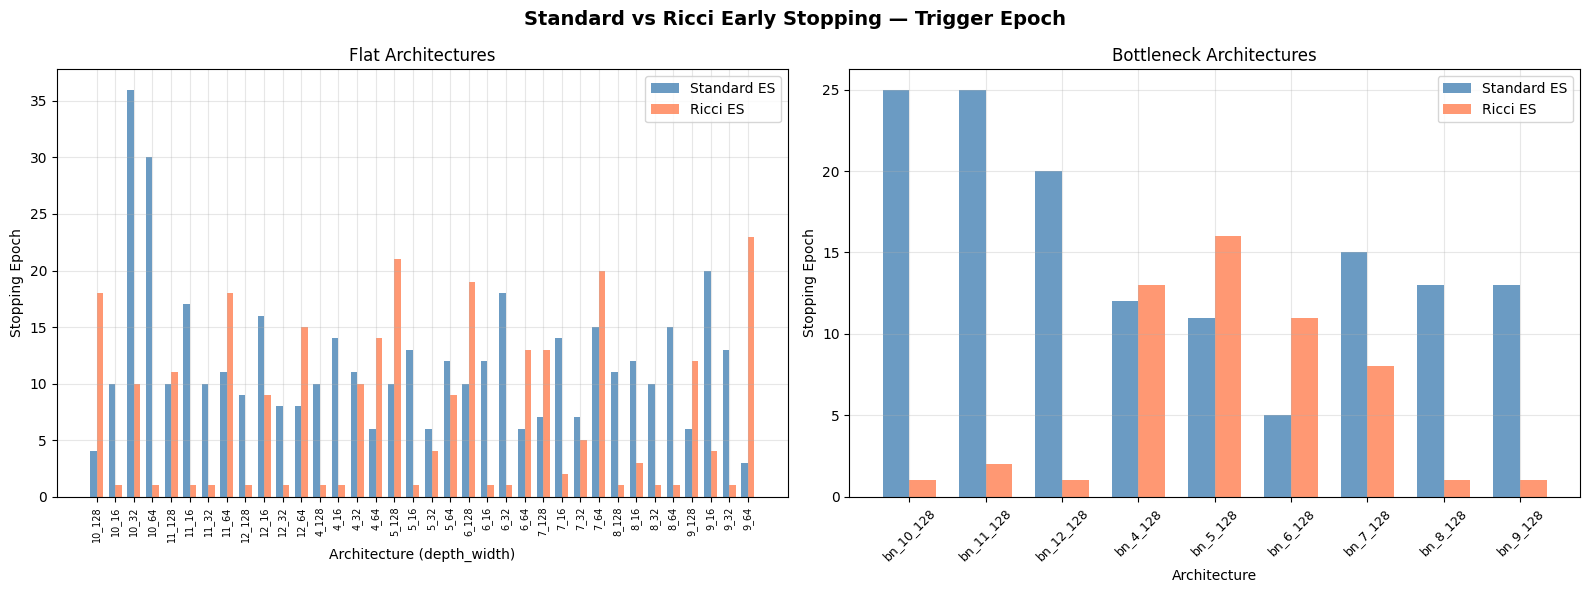

In [16]:
# ── Plot 1: Early Stopping Epoch Comparison ──
if not results_all:
    with open(os.path.join(OUTPUT_DIR, 'results_summary.json'), 'r') as f:
        results_all = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Separate flat and bottleneck
flat_results = [r for r in results_all if r['type'] == 'flat']
bn_results = [r for r in results_all if r['type'] == 'bottleneck']

# Plot flat architectures
ax = axes[0]
names = [r['name'].replace('flat_', '') for r in flat_results]
std_epochs = [r['std_es_epoch'] for r in flat_results]
ricci_epochs = [r['ricci_es_epoch'] for r in flat_results]
x = np.arange(len(names))
w = 0.35
ax.bar(x - w/2, std_epochs, w, label='Standard ES', color='steelblue', alpha=0.8)
ax.bar(x + w/2, ricci_epochs, w, label='Ricci ES', color='coral', alpha=0.8)
ax.set_xlabel('Architecture (depth_width)')
ax.set_ylabel('Stopping Epoch')
ax.set_title('Flat Architectures')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=90, fontsize=7)
ax.legend()
ax.grid(True, alpha=0.3)

# Plot bottleneck architectures
ax = axes[1]
names = [r['name'].replace('bottleneck_', 'bn_') for r in bn_results]
std_epochs = [r['std_es_epoch'] for r in bn_results]
ricci_epochs = [r['ricci_es_epoch'] for r in bn_results]
x = np.arange(len(names))
ax.bar(x - w/2, std_epochs, w, label='Standard ES', color='steelblue', alpha=0.8)
ax.bar(x + w/2, ricci_epochs, w, label='Ricci ES', color='coral', alpha=0.8)
ax.set_xlabel('Architecture')
ax.set_ylabel('Stopping Epoch')
ax.set_title('Bottleneck Architectures')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, fontsize=9)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Standard vs Ricci Early Stopping — Trigger Epoch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'es_epoch_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

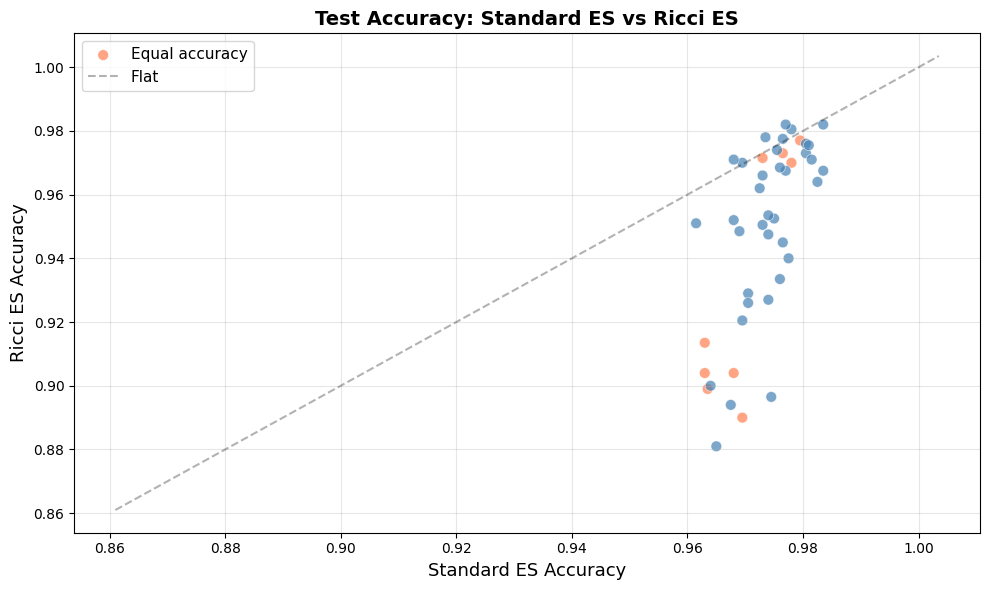

In [17]:
# ── Plot 2: Accuracy at Stopping Point ──
if not results_all:
    with open(os.path.join(OUTPUT_DIR, 'results_summary.json'), 'r') as f:
        results_all = json.load(f)

if not results_all:
    print('No results to plot. Run the main experiment loop first and ensure results_summary.json has data.')
else:
    fig, ax = plt.subplots(figsize=(10, 6))

    std_accs = [r['std_es_acc'] for r in results_all]
    ricci_accs = [r['ricci_es_acc'] for r in results_all]

    ax.scatter(std_accs, ricci_accs, c=['steelblue' if r['type']=='flat' else 'coral' for r in results_all],
               s=60, alpha=0.7, edgecolors='white', linewidths=0.5)

    # Diagonal line (equal accuracy)
    lims = [min(min(std_accs), min(ricci_accs)) - 0.02, max(max(std_accs), max(ricci_accs)) + 0.02]
    ax.plot(lims, lims, 'k--', alpha=0.3, label='Equal accuracy')

    ax.set_xlabel('Standard ES Accuracy', fontsize=13)
    ax.set_ylabel('Ricci ES Accuracy', fontsize=13)
    ax.set_title('Test Accuracy: Standard ES vs Ricci ES', fontsize=14, fontweight='bold')
    ax.legend(['Equal accuracy', 'Flat', 'Bottleneck'], fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'es_accuracy_comparison.png'), dpi=300, bbox_inches='tight')
    plt.show()

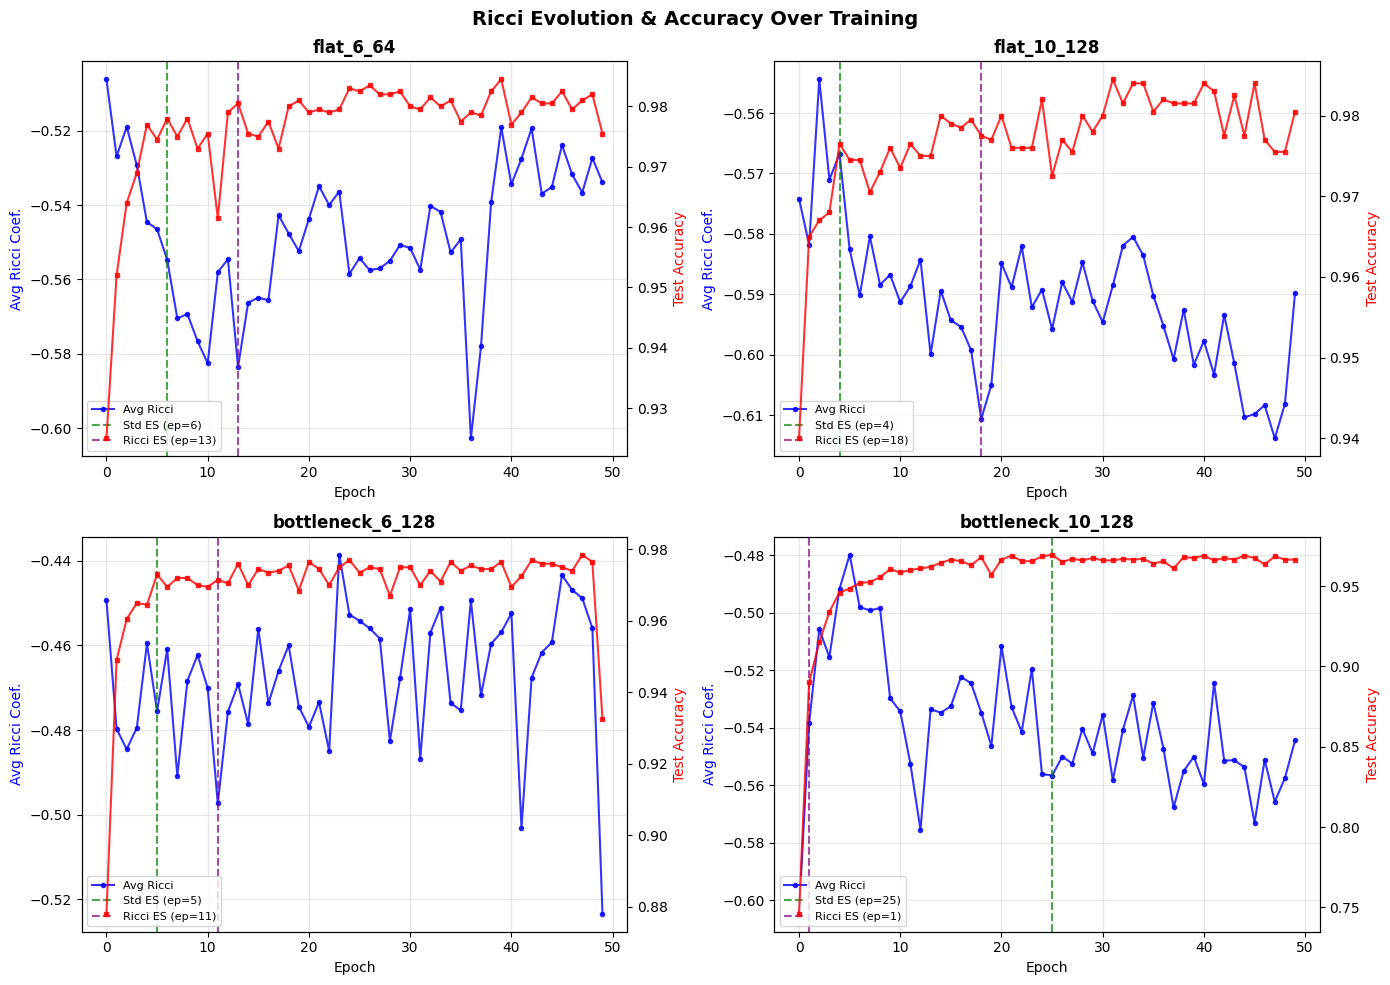

In [18]:
# ── Plot 3: Ricci Coefficient Evolution (sample architectures) ──
sample_models = ['flat_6_64', 'flat_10_128', 'bottleneck_6_128', 'bottleneck_10_128']
sample_models = [m for m in sample_models if os.path.exists(os.path.join(OUTPUT_DIR, m, 'epoch_history.json'))]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, model_name in enumerate(sample_models[:4]):
    ax = axes[idx]
    with open(os.path.join(OUTPUT_DIR, model_name, 'epoch_history.json'), 'r') as f:
        history = json.load(f)

    epochs = [h['epoch'] for h in history]
    avg_ricci = [h['avg_ricci'] for h in history]
    test_acc = [h['test_acc'] for h in history]

    ax2 = ax.twinx()
    ax.plot(epochs, avg_ricci, 'b-o', ms=3, label='Avg Ricci', alpha=0.8)
    ax2.plot(epochs, test_acc, 'r-s', ms=3, label='Test Acc', alpha=0.8)

    # Mark ES points
    std_ep = int(np.load(os.path.join(OUTPUT_DIR, model_name, 'standard_es_epoch.npy'))[0])
    ricci_ep = int(np.load(os.path.join(OUTPUT_DIR, model_name, 'ricci_es_epoch.npy'))[0])
    ax.axvline(std_ep, color='green', ls='--', alpha=0.7, label=f'Std ES (ep={std_ep})')
    ax.axvline(ricci_ep, color='purple', ls='--', alpha=0.7, label=f'Ricci ES (ep={ricci_ep})')

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Avg Ricci Coef.', color='blue')
    ax2.set_ylabel('Test Accuracy', color='red')
    ax.set_title(model_name, fontweight='bold')
    ax.legend(loc='lower left', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Ricci Evolution & Accuracy Over Training', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ricci_evolution_samples.png'), dpi=300, bbox_inches='tight')
plt.show()

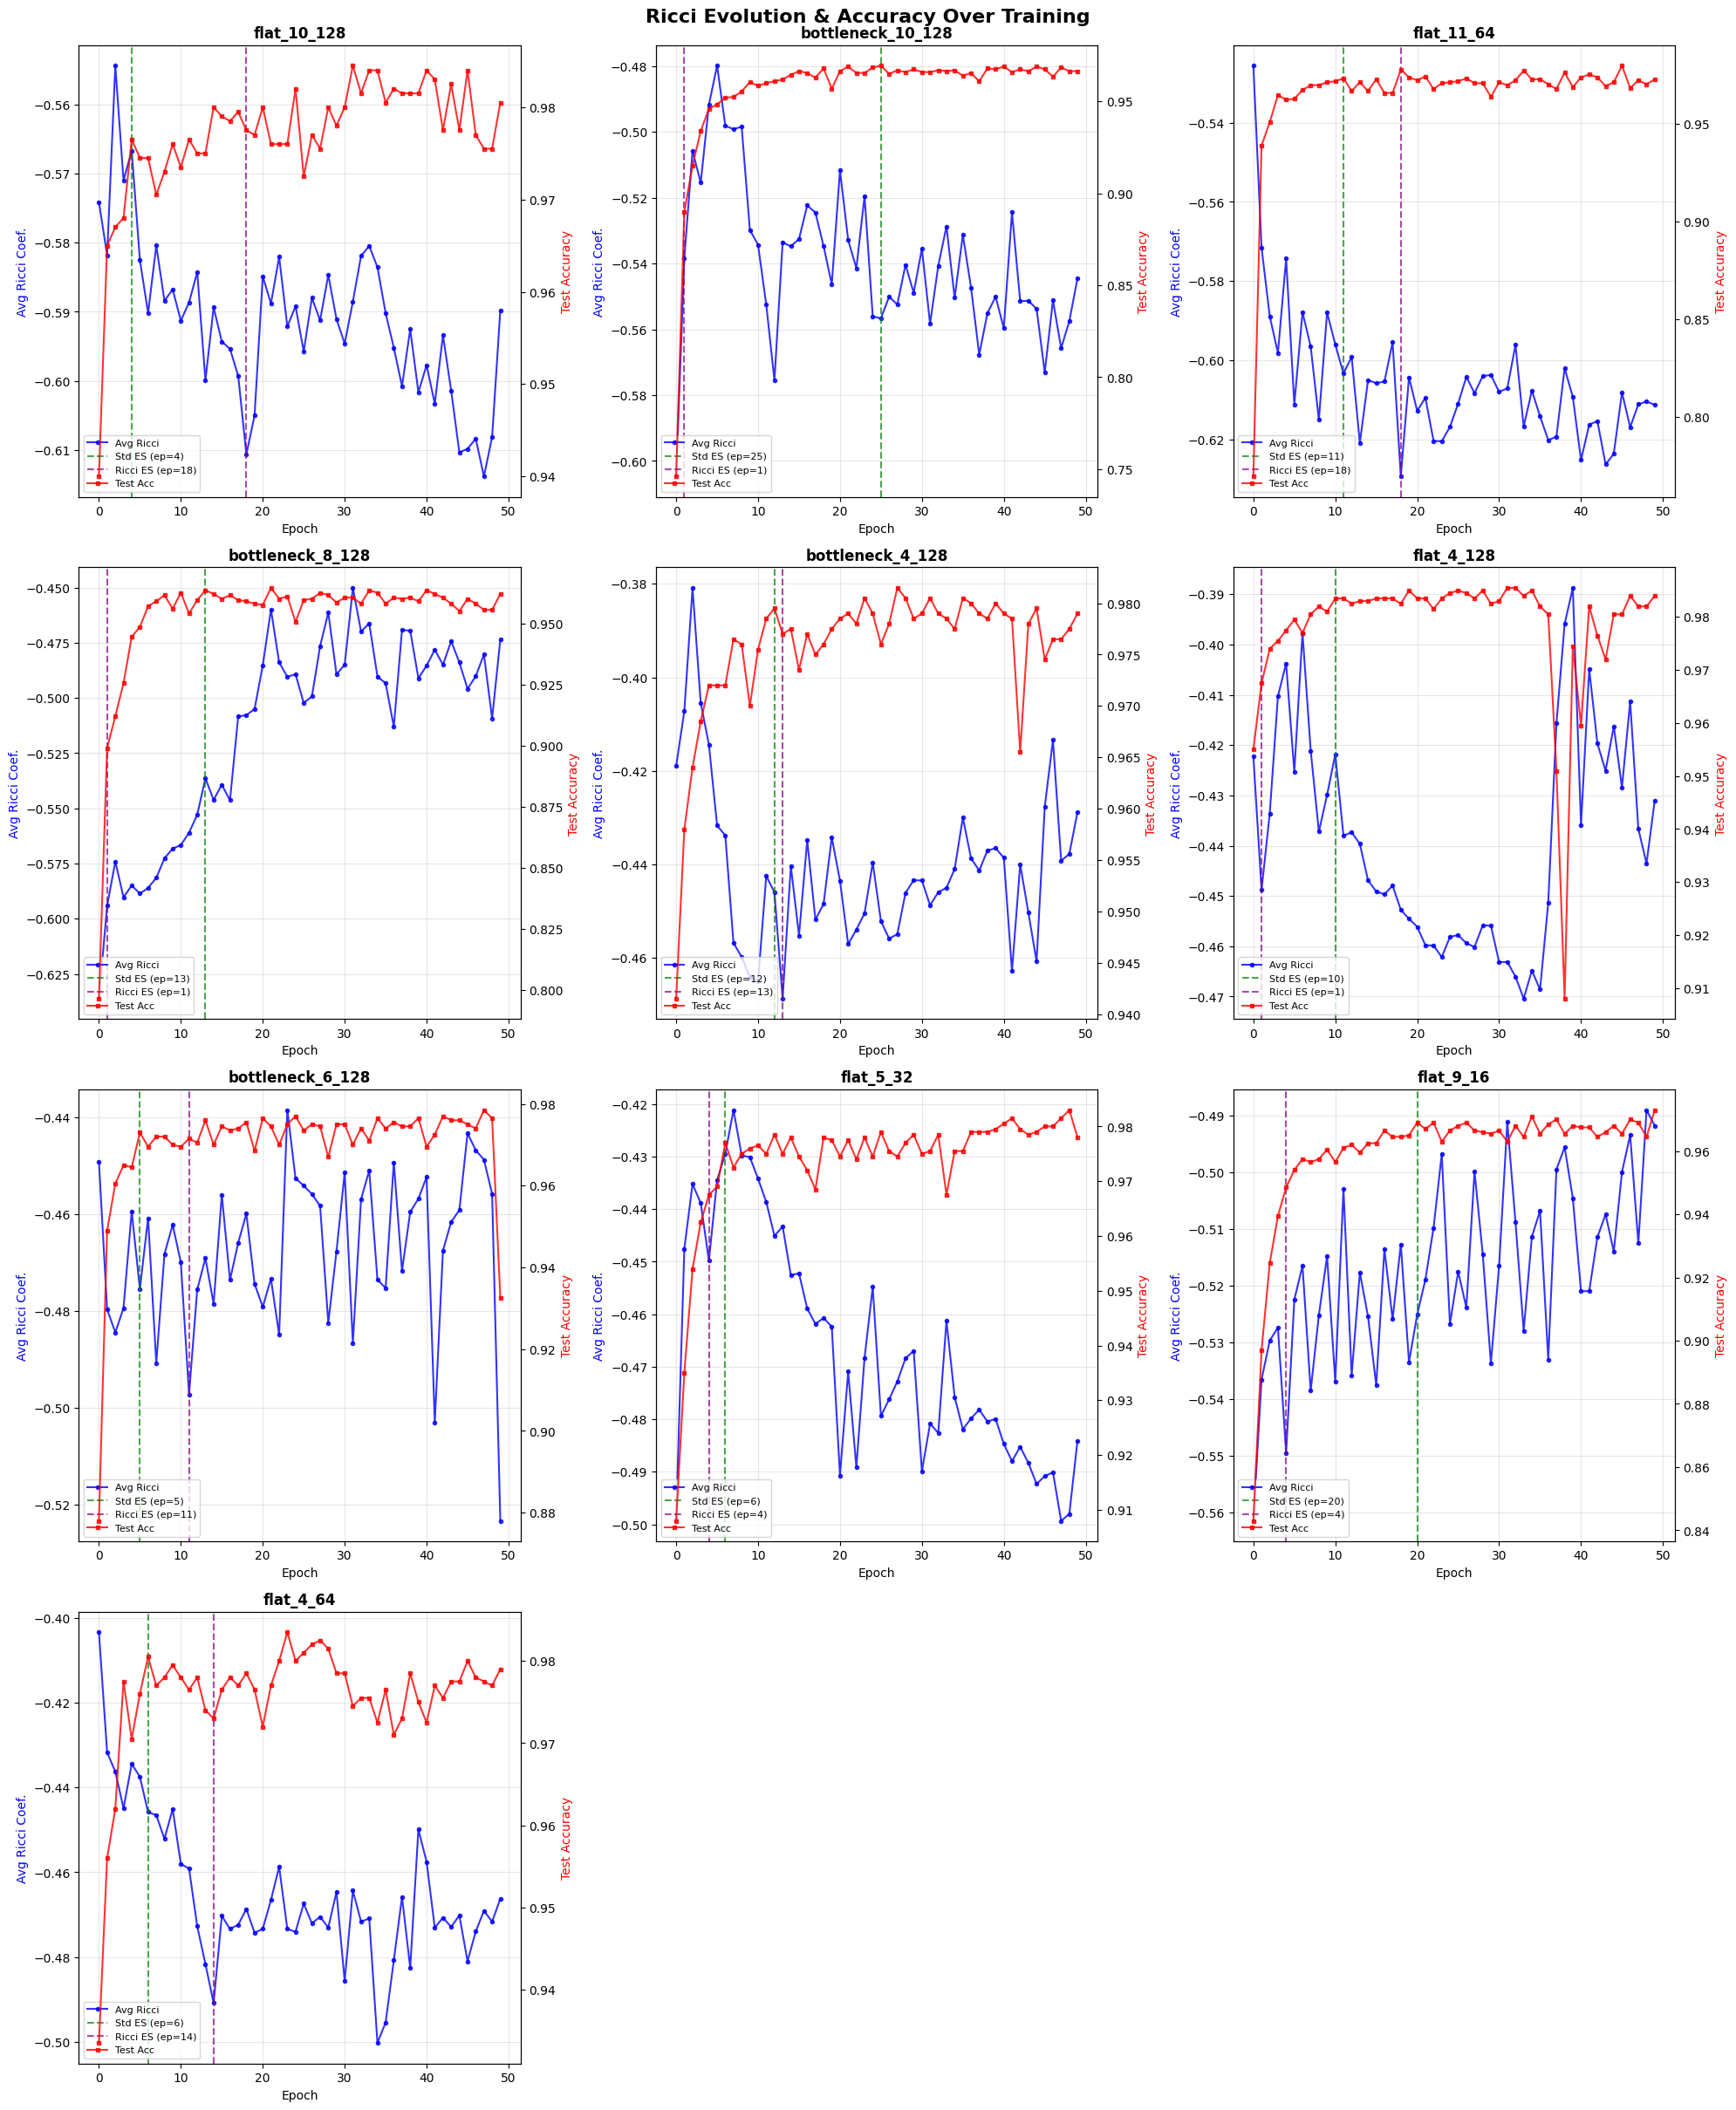

In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# ── Plot 3: Ricci Coefficient Evolution (sample architectures) ──

sample_models = [
    
    'flat_10_128', 'bottleneck_10_128', 'flat_11_64', 'bottleneck_8_128',
    
    'bottleneck_4_128', 'flat_4_128',
    
    'bottleneck_6_128', 'flat_5_32',
    
    'flat_9_16', 'flat_4_64'
]

# Filter models that actually exist in the output directory
sample_models = [m for m in sample_models if os.path.exists(os.path.join(OUTPUT_DIR, m, 'epoch_history.json'))]

# Define grid size for up to 10 plots (5 rows, 3 columns)
nrows, ncols = 5, 3
num_models = min(len(sample_models), 10)

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 30))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    if idx < num_models:
        model_name = sample_models[idx]
        with open(os.path.join(OUTPUT_DIR, model_name, 'epoch_history.json'), 'r') as f:
            history = json.load(f)

        epochs = [h['epoch'] for h in history]
        avg_ricci = [h['avg_ricci'] for h in history]
        test_acc = [h['test_acc'] for h in history]

        ax2 = ax.twinx()
        ax.plot(epochs, avg_ricci, 'b-o', ms=3, label='Avg Ricci', alpha=0.8)
        ax2.plot(epochs, test_acc, 'r-s', ms=3, label='Test Acc', alpha=0.8)

        # Mark ES points
        std_ep = int(np.load(os.path.join(OUTPUT_DIR, model_name, 'standard_es_epoch.npy'))[0])
        ricci_ep = int(np.load(os.path.join(OUTPUT_DIR, model_name, 'ricci_es_epoch.npy'))[0])
        ax.axvline(std_ep, color='green', ls='--', alpha=0.7, label=f'Std ES (ep={std_ep})')
        ax.axvline(ricci_ep, color='purple', ls='--', alpha=0.7, label=f'Ricci ES (ep={ricci_ep})')

        ax.set_xlabel('Epoch')
        ax.set_ylabel('Avg Ricci Coef.', color='blue')
        ax2.set_ylabel('Test Accuracy', color='red')
        ax.set_title(model_name, fontweight='bold')

        # Combined legend for both axes
        lines_1, labels_1 = ax.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower left', fontsize=8)

        ax.grid(True, alpha=0.3)
    else:

        ax.set_visible(False)

plt.suptitle('Ricci Evolution & Accuracy Over Training', fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ricci_evolution_samples_10.png'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import os
import json
import csv
import numpy as np

# Load results
if 'results_all' not in dir() or not results_all:
    path = os.path.join(OUTPUT_DIR, 'results_summary.json')
    if os.path.exists(path):
        with open(path, 'r') as f:
            results_all = json.load(f)
    else:
        results_all = []

# Max transitions with features[1:] at depth=12: (12 hidden + 1 output) - 1 = 12
max_layers = 12
rows = []

for r in results_all:
    name = r['name']
    model_dir = os.path.join(OUTPUT_DIR, name)
    hist_path = os.path.join(model_dir, 'epoch_history.json')

    std_es_epoch = r['std_es_epoch']
    ricci_es_epoch = r['ricci_es_epoch']
    std_es_acc = r['std_es_acc']
    ricci_es_acc = r['ricci_es_acc']

    avg_ricci_at_std = np.nan
    avg_ricci_at_ricci = np.nan
    last_transition_ricci_at_ricci = np.nan
    layer_ricci_at_ricci = [np.nan] * max_layers

    if os.path.exists(hist_path):
        with open(hist_path, 'r') as f:
            history = json.load(f)
        by_epoch = {h['epoch']: h for h in history}

        if std_es_epoch in by_epoch:
            avg_ricci_at_std = by_epoch[std_es_epoch]['avg_ricci']
        if ricci_es_epoch in by_epoch:
            avg_ricci_at_ricci = by_epoch[ricci_es_epoch]['avg_ricci']
            lr = by_epoch[ricci_es_epoch].get('layer_ricci', [])
            if len(lr) > 0:
                last_transition_ricci_at_ricci = lr[-1]
            else:
                last_transition_ricci_at_ricci = by_epoch[ricci_es_epoch].get('last_transition_ricci', np.nan)
            for i, v in enumerate(lr):
                if i < max_layers:
                    layer_ricci_at_ricci[i] = v

    row = {
        'name': name,
        'type': r['type'],
        'depth': r['depth'],
        'width': r['width'],
        'std_es_epoch': std_es_epoch,
        'ricci_es_epoch': ricci_es_epoch,
        'std_es_acc': std_es_acc,
        'ricci_es_acc': ricci_es_acc,
        'avg_ricci_at_std_es': avg_ricci_at_std,
        'avg_ricci_at_ricci_es': avg_ricci_at_ricci,
        'last_transition_ricci_at_ricci_es': last_transition_ricci_at_ricci,
    }
    for i in range(max_layers):
        row[f'layer_{i}_ricci_at_ricci_es'] = layer_ricci_at_ricci[i]
    rows.append(row)

# Write CSV
csv_path = os.path.join(OUTPUT_DIR, 'all_models_summary.csv')
fieldnames = [
    'name', 'type', 'depth', 'width',
    'std_es_epoch', 'ricci_es_epoch',
    'std_es_acc', 'ricci_es_acc',
    'avg_ricci_at_std_es', 'avg_ricci_at_ricci_es',
    'last_transition_ricci_at_ricci_es'
] + [f'layer_{i}_ricci_at_ricci_es' for i in range(max_layers)]

with open(csv_path, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=fieldnames)
    w.writeheader()
    w.writerows(rows)

print(f'Saved {len(rows)} rows to {csv_path}')

Saved 45 rows to /content/drive/MyDrive/Ricci_Flow_Experiment/early_stopping_experiment/all_models_summary.csv


In [ ]:
# Export CSV with Ricci at Ricci ES (recomputed with features[1:] so output layer is included)

import csv
import json

if 'results_all' not in dir() or not results_all:
    with open(os.path.join(OUTPUT_DIR, 'results_summary.json'), 'r') as f:
        results_all = json.load(f)

CHECKPOINT_CSV_PATH = os.path.join(OUTPUT_DIR, 'csv_export_checkpoint.json')

def _row_to_json(row):
    """Replace float('nan') with None so checkpoint is JSON-serializable."""
    out = {}
    for k, v in row.items():
        if isinstance(v, float) and np.isnan(v):
            out[k] = None
        else:
            out[k] = v
    return out

def _load_checkpoint():
    if os.path.exists(CHECKPOINT_CSV_PATH):
        with open(CHECKPOINT_CSV_PATH, 'r') as f:
            return json.load(f)
    return {}

def _save_checkpoint(rows_by_name):
    to_save = {name: _row_to_json(row) for name, row in rows_by_name.items()}
    with open(CHECKPOINT_CSV_PATH, 'w') as f:
        json.dump(to_save, f, indent=0)

max_layers = 12
total = len(results_all)
rows_by_name = _load_checkpoint()

for idx, r in enumerate(results_all):
    name = r['name']
    step = idx + 1
    if name in rows_by_name:
        print(f"[{step:2d}/{total}] {name} — skipped (in checkpoint)")
        continue

    print(f"[{step:2d}/{total}] {name} — computing Ricci...")
    arch_type, depth, width = r['type'], r['depth'], r['width']
    std_es_epoch = r['std_es_epoch']
    ricci_es_epoch = r['ricci_es_epoch']
    std_es_acc = r['std_es_acc']
    ricci_es_acc = r['ricci_es_acc']

    model_dir = os.path.join(OUTPUT_DIR, name)
    weights_path = os.path.join(model_dir, 'model_weights_ricci.pth')

    avg_ricci_at_ricci_es = np.nan
    last_transition_ricci_at_ricci_es = np.nan
    layer_ricci_list = [np.nan] * max_layers

    if os.path.exists(weights_path):
        model = build_model(arch_type, depth, width)
        model.load_state_dict(torch.load(weights_path, map_location=device))
        model.eval()
        with torch.inference_mode():
            features = model.features(X_test)

        hidden_acts = features[1:]
        if len(hidden_acts) < 2:
            raise ValueError(f"{name}: expected at least 2 feature tensors, got {len(hidden_acts)}")

        penultimate_acts = hidden_acts[-2]
        output_acts = hidden_acts[-1]
        if penultimate_acts.ndim != 2 or output_acts.ndim != 2:
            raise ValueError(
                f"{name}: expected 2D activations, got penultimate={penultimate_acts.shape}, output={output_acts.shape}"
            )
        if penultimate_acts.shape[0] != output_acts.shape[0]:
            raise ValueError(
                f"{name}: sample dimension mismatch for last transition: "
                f"penultimate={penultimate_acts.shape}, output={output_acts.shape}"
            )

        layer_ricci = compute_ricci_from_features(hidden_acts, K, curv=CURVATURE_TYPE)
        expected_transitions = len(hidden_acts) - 1
        if len(layer_ricci) != expected_transitions:
            raise ValueError(
                f"{name}: Ricci length mismatch. expected={expected_transitions}, got={len(layer_ricci)}"
            )

        avg_ricci, excluded_layers = robust_avg_ricci_threshold(layer_ricci)
        last_transition_ricci_at_ricci_es = float(layer_ricci[-1])

        for i, v in enumerate(layer_ricci):
            if i < max_layers:
                layer_ricci_list[i] = float(v) if not np.isnan(v) else np.nan

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    avg_ricci_at_std_es = np.nan
    hist_path = os.path.join(model_dir, 'epoch_history.json')
    if os.path.exists(hist_path):
        with open(hist_path, 'r') as f:
            history = json.load(f)
        by_epoch = {h['epoch']: h for h in history}
        if std_es_epoch in by_epoch and 'avg_ricci' in by_epoch[std_es_epoch]:
            avg_ricci_at_std_es = by_epoch[std_es_epoch]['avg_ricci']

    row = {
        'name': name, 'type': arch_type, 'depth': depth, 'width': width,
        'std_es_epoch': std_es_epoch, 'ricci_es_epoch': ricci_es_epoch,
        'std_es_acc': std_es_acc, 'ricci_es_acc': ricci_es_acc,
        'avg_ricci_at_std_es': avg_ricci_at_std_es,
        'avg_ricci_at_ricci_es': avg_ricci_at_ricci_es,
        'last_transition_ricci_at_ricci_es': last_transition_ricci_at_ricci_es,
    }
    for i in range(max_layers):
        row[f'layer_{i}_ricci_at_ricci_es'] = layer_ricci_list[i]
    rows_by_name[name] = row
    _save_checkpoint(rows_by_name)

# Build final rows in results_all order; restore nan for CSV
rows = []
for r in results_all:
    name = r['name']
    row = rows_by_name.get(name)
    if row is None:
        continue
    for k, v in row.items():
        if v is None:
            row[k] = np.nan
    rows.append(row)

csv_path = os.path.join(OUTPUT_DIR, 'experiment_early_stopping.csv')
fieldnames = (
    ['name', 'type', 'depth', 'width', 'std_es_epoch', 'ricci_es_epoch', 'std_es_acc', 'ricci_es_acc',
     'avg_ricci_at_std_es', 'avg_ricci_at_ricci_es', 'last_transition_ricci_at_ricci_es'] +
    [f'layer_{i}_ricci_at_ricci_es' for i in range(max_layers)]
)
with open(csv_path, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=fieldnames)
    w.writeheader()
    w.writerows(rows)
print(f"Saved {len(rows)} rows to {csv_path}")

[ 1/45] bottleneck_10_128 — skipped (in checkpoint)
[ 2/45] bottleneck_11_128 — skipped (in checkpoint)
[ 3/45] bottleneck_12_128 — skipped (in checkpoint)
[ 4/45] bottleneck_4_128 — skipped (in checkpoint)
[ 5/45] bottleneck_5_128 — skipped (in checkpoint)
[ 6/45] bottleneck_6_128 — skipped (in checkpoint)
[ 7/45] bottleneck_7_128 — skipped (in checkpoint)
[ 8/45] bottleneck_8_128 — skipped (in checkpoint)
[ 9/45] bottleneck_9_128 — skipped (in checkpoint)
[10/45] flat_10_128 — skipped (in checkpoint)
[11/45] flat_10_16 — skipped (in checkpoint)
[12/45] flat_10_32 — skipped (in checkpoint)
[13/45] flat_10_64 — skipped (in checkpoint)
[14/45] flat_11_128 — skipped (in checkpoint)
[15/45] flat_11_16 — skipped (in checkpoint)
[16/45] flat_11_32 — skipped (in checkpoint)
[17/45] flat_11_64 — skipped (in checkpoint)
[18/45] flat_12_128 — skipped (in checkpoint)
[19/45] flat_12_16 — skipped (in checkpoint)
[20/45] flat_12_32 — skipped (in checkpoint)
[21/45] flat_12_64 — skipped (in checkpo

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# SWEEP ALL 5 ROBUST AVERAGING FUNCTIONS & SAVE RESULTS TO CSV
# ═══════════════════════════════════════════════════════════════════════

import csv

robust_methods = {
    'iqr':         robust_avg_ricci_iqr,
    'zscore':      robust_avg_ricci_zscore,
    'progressive': robust_avg_ricci_progressive,
    'tail_drop':   robust_avg_ricci_tail_drop,
    'threshold':   robust_avg_ricci_threshold,
}

for method_name, robust_fn in robust_methods.items():
    print(f'\n{"="*60}')
    print(f'Running sweep with method: {method_name}')
    print(f'{"="*60}')

    results = []

    for arch_idx, (name, arch_type, depth, width) in enumerate(ARCHITECTURES):
        model_dir = os.path.join(OUTPUT_DIR, name)
        hist_path = os.path.join(model_dir, 'epoch_history.json')

        if not os.path.exists(hist_path):
            print(f'  [{arch_idx+1}/{len(ARCHITECTURES)}] {name} — SKIPPED (no history)')
            continue

        with open(hist_path, 'r') as f:
            epoch_data = json.load(f)

        # Fresh early-stopping observers for each architecture
        std_es  = StandardEarlyStopping(patience=PATIENCE)
        ricci_es = RicciEarlyStopping(patience=PATIENCE)

        for entry in epoch_data:
            epoch      = entry['epoch']
            test_acc   = entry['test_acc']
            layer_ricci = np.array(entry['layer_ricci'])

            avg_ricci, excluded = robust_fn(layer_ricci)

            std_es.step(epoch, test_acc)
            ricci_es.step(epoch, avg_ricci)

        last_epoch        = len(epoch_data) - 1
        std_report_epoch  = max(0, min(int(std_es.best_epoch  or last_epoch), last_epoch))
        ricci_report_epoch = max(0, min(int(ricci_es.best_epoch or last_epoch), last_epoch))

        std_acc   = float(epoch_data[std_report_epoch]['test_acc'])
        ricci_acc = float(epoch_data[ricci_report_epoch]['test_acc'])

        results.append({
            'name':             name,
            'type':             arch_type,
            'depth':            depth,
            'width':            width,
            'method':           method_name,
            'std_es_epoch':     std_report_epoch,
            'ricci_es_epoch':   ricci_report_epoch,
            'std_es_acc':       round(std_acc, 4),
            'ricci_es_acc':     round(ricci_acc, 4),
            'std_es_stopped':   std_es.stop_epoch is not None,
            'ricci_es_stopped': ricci_es.stop_epoch is not None,
            'std_stop_epoch':   std_es.stop_epoch,
            'ricci_stop_epoch': ricci_es.stop_epoch,
        })

    # ── Save CSV ──
    csv_path = os.path.join(OUTPUT_DIR, f'results_sweep_{method_name}.csv')
    if results:
        fieldnames = list(results[0].keys())
        with open(csv_path, 'w', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(results)

    # ── Print summary ──
    ricci_earlier = sum(1 for r in results if r['ricci_es_epoch'] < r['std_es_epoch'])
    std_earlier   = sum(1 for r in results if r['std_es_epoch']   < r['ricci_es_epoch'])
    ties          = sum(1 for r in results if r['std_es_epoch']  == r['ricci_es_epoch'])
    avg_std_acc   = np.mean([r['std_es_acc']   for r in results]) if results else 0
    avg_ricci_acc = np.mean([r['ricci_es_acc']  for r in results]) if results else 0

    print(f'  Ricci earlier: {ricci_earlier}  |  Standard earlier: {std_earlier}  |  Tie: {ties}')
    print(f'  Avg accuracy — Standard: {avg_std_acc:.4f}, Ricci: {avg_ricci_acc:.4f}')
    print(f'  Saved → {csv_path}')

print(f'\n Sweep complete! All 5 CSV files saved to {OUTPUT_DIR}')



Running sweep with method: iqr
  Ricci earlier: 44  |  Standard earlier: 1  |  Tie: 0
  Avg accuracy — Standard: 0.9734, Ricci: 0.9435
  ✅ Saved → /content/drive/MyDrive/Ricci_Flow_Experiment/early_stopping_experiment/results_sweep_iqr.csv

Running sweep with method: zscore
  Ricci earlier: 43  |  Standard earlier: 2  |  Tie: 0
  Avg accuracy — Standard: 0.9734, Ricci: 0.9441
  ✅ Saved → /content/drive/MyDrive/Ricci_Flow_Experiment/early_stopping_experiment/results_sweep_zscore.csv

Running sweep with method: progressive
  Ricci earlier: 44  |  Standard earlier: 1  |  Tie: 0
  Avg accuracy — Standard: 0.9734, Ricci: 0.9414
  ✅ Saved → /content/drive/MyDrive/Ricci_Flow_Experiment/early_stopping_experiment/results_sweep_progressive.csv

Running sweep with method: tail_drop
  Ricci earlier: 45  |  Standard earlier: 0  |  Tie: 0
  Avg accuracy — Standard: 0.9734, Ricci: 0.9456
  ✅ Saved → /content/drive/MyDrive/Ricci_Flow_Experiment/early_stopping_experiment/results_sweep_tail_drop.csv

R